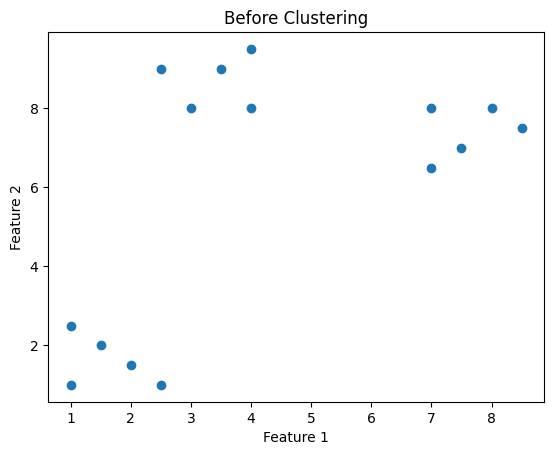

In [28]:
# Manual Implementation
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [1.0, 1.0],
    [1.5, 2.0],
    [2.0, 1.5],
    [1.0, 2.5],
    [2.5, 1.0],

    [7.0, 8.0],
    [8.0, 8.0],
    [7.5, 7.0],
    [8.5, 7.5],
    [7.0, 6.5],

    [3.0, 8.0],
    [3.5, 9.0],
    [4.0, 8.0],
    [2.5, 9.0],
    [4.0, 9.5]
])

plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Before Clustering")
plt.show()

In [29]:
# Number of centroids
K = 3


# Function for creating cetroids randomly
def create_centroids(X: np.array, num_centroid: int):
  centroids = np.random.uniform(
    low = X.min(axis = 0),
    high = X.max(axis = 0),
    size = (num_centroid, X.shape[1])
    )

  return centroids

# Create centroid
centroids = create_centroids(X, K)
print(centroids)

[[4.92543184 1.97553541]
 [7.4510477  7.14392158]
 [1.50751271 7.01659833]]


In [30]:
# Function to which centroid does each point belong
def map_centroid(X: np.array, centroids: np.array):
  distances = []
  assigned_centroid = []

  for i in range(X.shape[0]):
    for j in range(len(centroids)):
      distance = np.sqrt(np.sum((X[i] - centroids[j])**2))  # Don't be scared
      distances.append(distance)

    assigned_centroid.append(distances.index(min(distances))) # here too
    distances = []


  return assigned_centroid


assign_centroid = map_centroid(X, centroids)
print(assign_centroid)

[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2]


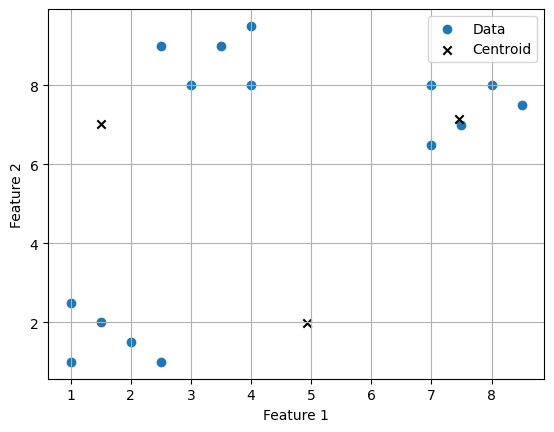

In [31]:
# Plot current cetroids
def plot_centroid(X, centroids):
  plt.scatter(X[:, 0], X[:, 1], label = "Data")
  plt.scatter(centroids[:, 0], centroids[:, 1], marker = "x", color = "black", label = "Centroid")
  plt.xlabel("Feature 1")
  plt.ylabel("Feature 2")
  plt.legend()
  plt.grid()
  plt.show()

plot_centroid(X, centroids)

In [32]:
# Update centroids -> Issue: if some centroid has nan it will crash
def update_centroids(X: np.array, num_centroid: int, assigned_centroids: list):

  new_centroids = []

  for j in range(num_centroid):

      elems = [X[i] for i in range(len(assigned_centroids))
              if assigned_centroids[i] == j]

      new_centroids.append(np.mean(elems, axis=0))

  new_centroids = np.array(new_centroids)

  return new_centroids


new_centroids = update_centroids(X, K, assign_centroid)
print(new_centroids)

[[1.6 1.6]
 [7.6 7.4]
 [3.4 8.7]]


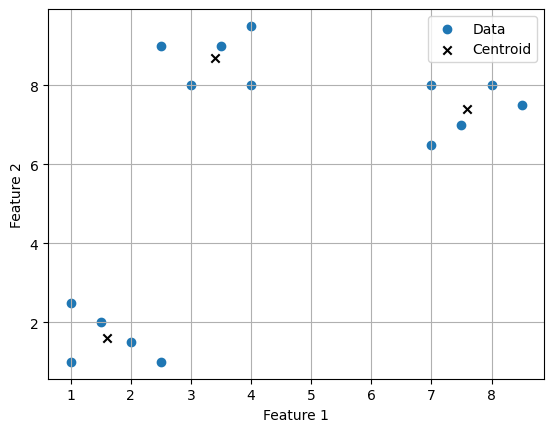

In [33]:
# Plot new centroids
# As you can see they are shifted
plot_centroid(X, new_centroids)

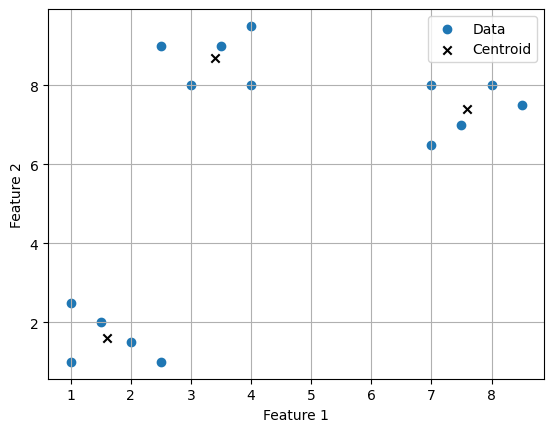

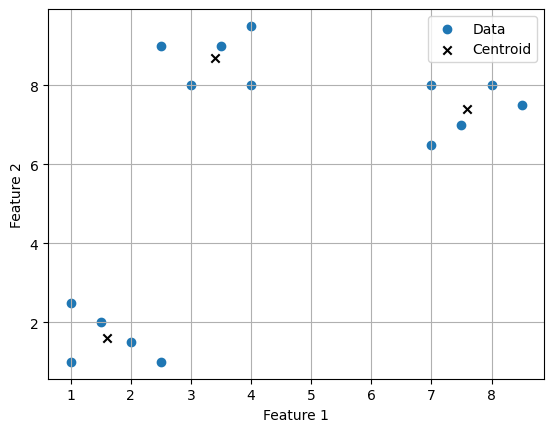

In [34]:
# Many loops of updates
for i in range(20):
  assign_centroid = map_centroid(X, centroids)
  new_centroids = update_centroids(X, K, assign_centroid)

  plot_centroid(X, new_centroids)

  if np.allclose(new_centroids, centroids):
    break

  centroids = new_centroids

In [35]:
# Create one function for all: kmean(X, K) function -> with input X and number of clusters K
# Random initialization may produce an empty cluster (NaN).
# If this happens, generate new random centroids and restart.
# If runtime got too long please stop the process and rerun with smaller number of clusters
# Check graph
def kmean(X: np.array, num_cluster: int):
  if num_cluster > len(X):
    return "ERROR: Number of clusters must be less or equl to length of array X"
  while True:

    try:
      clusters = create_centroids(X, num_cluster)
      map_xclust = map_centroid(X, clusters)
      update_cluster = update_centroids(X, num_cluster, map_xclust)

      break

    except:
      continue

  while True:
    map_xclust = map_centroid(X, clusters)
    new_cluster = update_centroids(X, num_cluster, map_xclust)

    if np.allclose(new_cluster, clusters):
      break

    clusters = new_cluster


  return new_cluster, map_xclust


[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2]


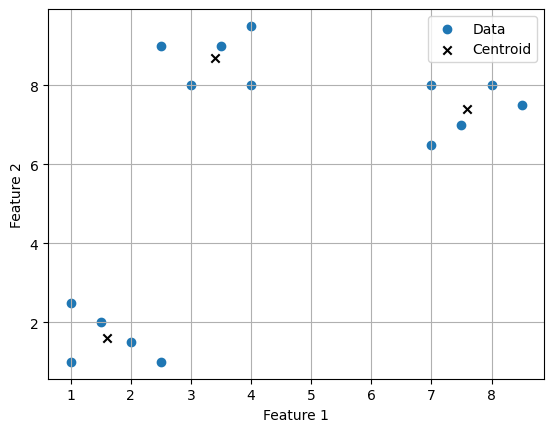

In [36]:
cluster, map_clst = kmean(X, 3)
print(map_clst)
plot_centroid(X, cluster)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


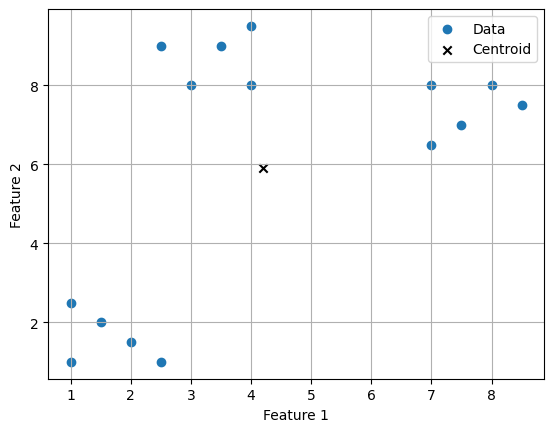

[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


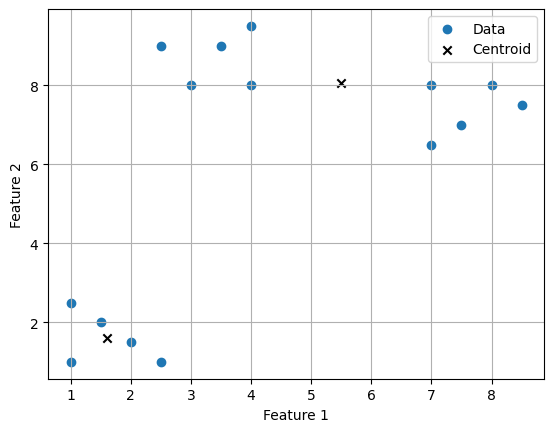

[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2]


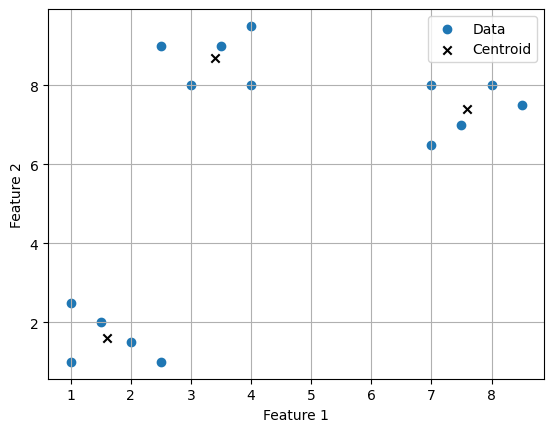

[0, 0, 0, 0, 0, 3, 3, 3, 3, 3, 2, 2, 1, 2, 2]


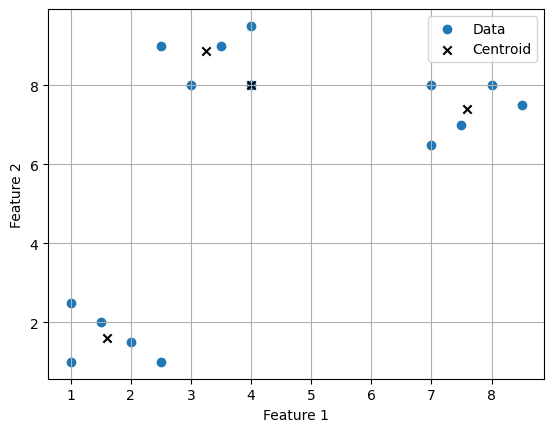

[0, 0, 0, 2, 0, 1, 1, 4, 4, 4, 3, 3, 3, 3, 3]


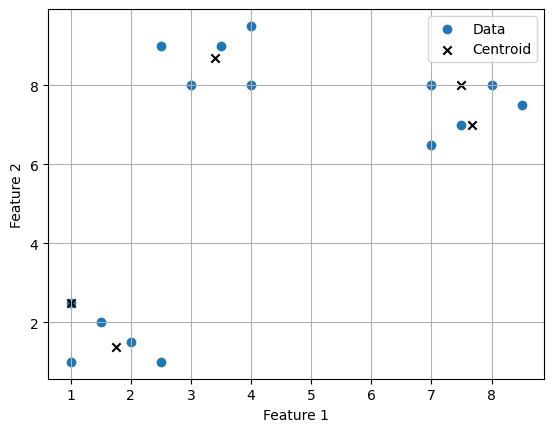

In [39]:
# Some checkings
for i in range(1, 6):
  clus, map_clut = kmean(X, i)
  print(map_clut)
  plot_centroid(X, clus)

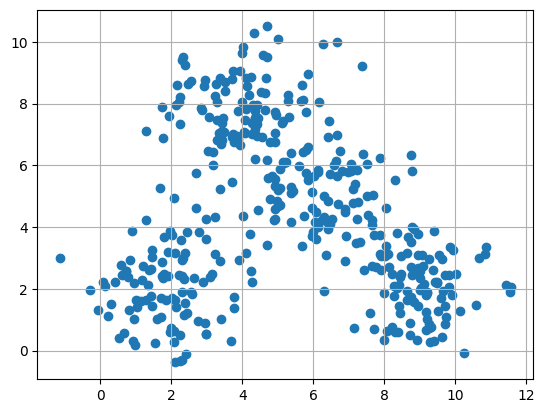

In [40]:
# More checking
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

cluster1 = np.random.normal([2, 2], 1.2, (100, 2))
cluster2 = np.random.normal([6, 5], 1.3, (100, 2))
cluster3 = np.random.normal([4, 8], 1.1, (100, 2))
cluster4 = np.random.normal([9, 2], 1.0, (100, 2))

X = np.vstack((cluster1, cluster2, cluster3, cluster4))

plt.scatter(X[:,0], X[:,1])
plt.grid(True)
plt.show()

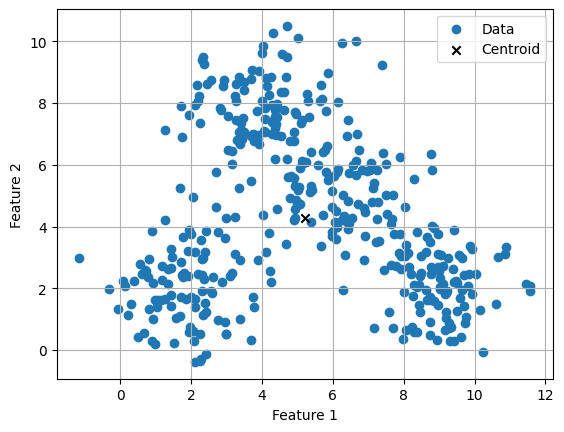

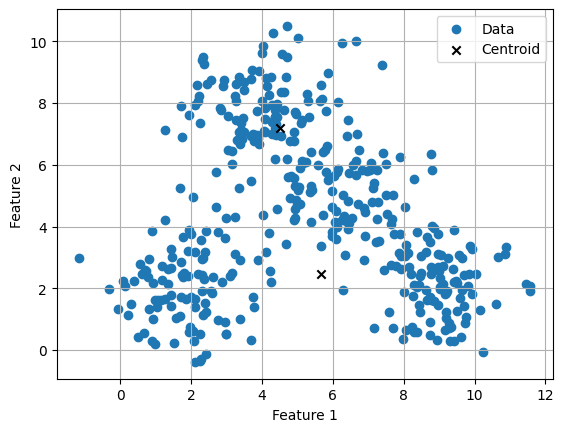

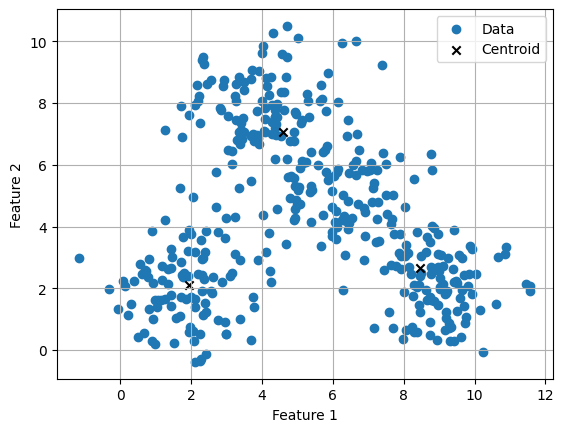

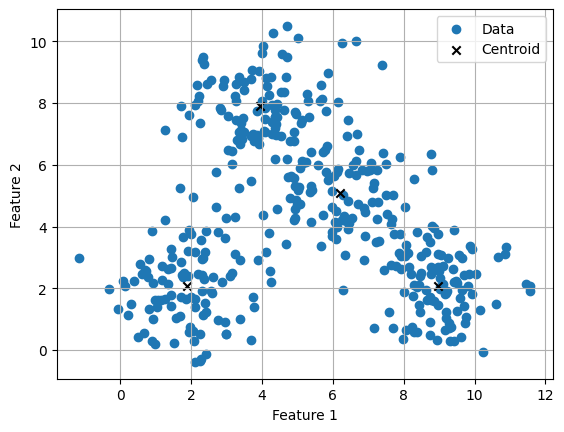

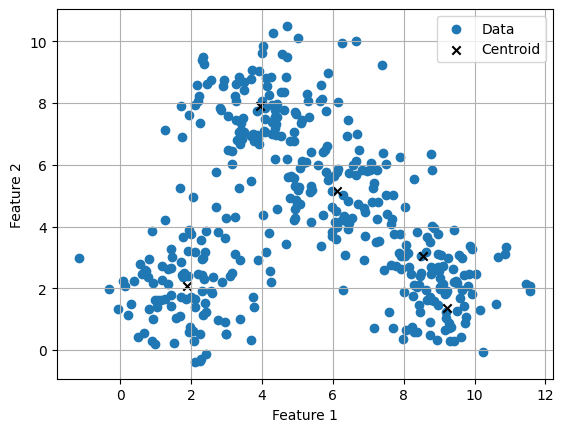

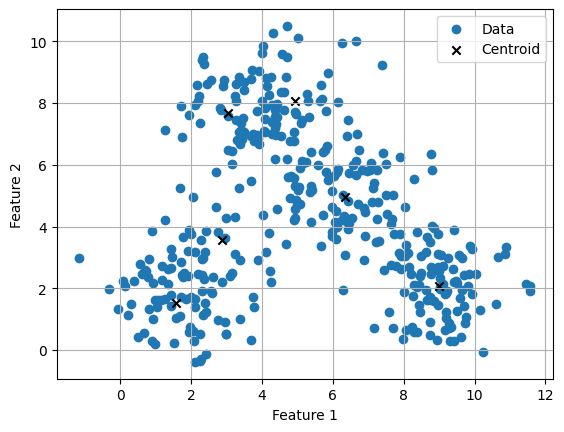

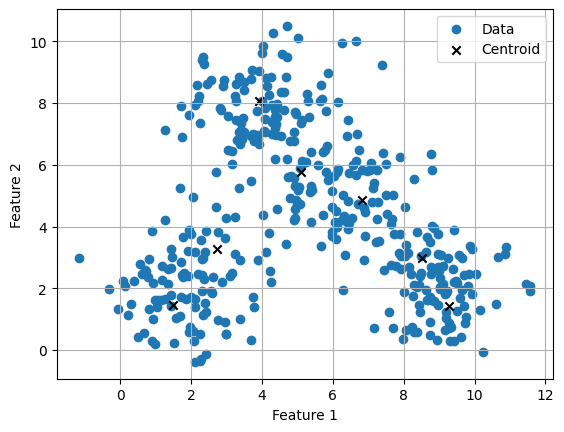

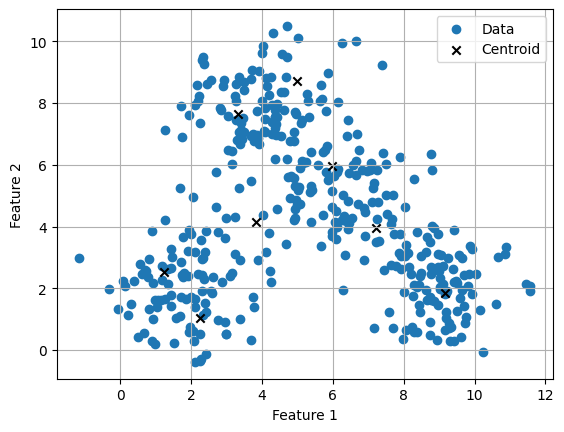

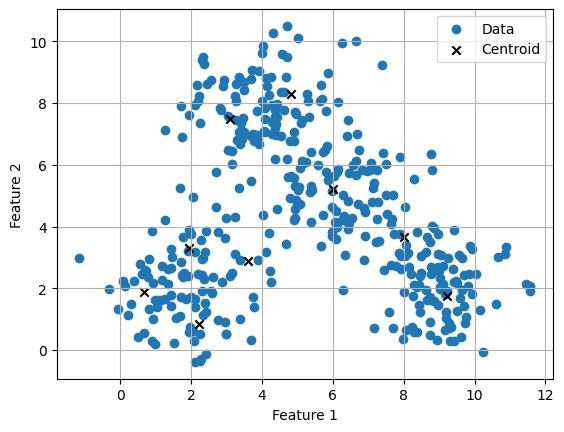

In [42]:
for i in range(1, 10):
  clst, map_clst = kmean(X, i)
  plot_centroid(X, clst)